
Tramo 1  (válido para x en [-1, 0]):
  En forma (x - x0):
    S_0(x) = 1.000000 + (0.000000)(x--1) + (10.000000)(x--1)^2 + (-6.000000)(x--1)^3
  Expandido:
    S_0(x) = -6.0*x**3 - 8.0*x**2 + 2.0*x + 5.0

Tramo 2  (válido para x en [0, 1]):
  En forma (x - x1):
    S_1(x) = 5.000000 + (2.000000)(x-0) + (-8.000000)(x-0)^2 + (4.000000)(x-0)^3
  Expandido:
    S_1(x) = 4.0*x**3 - 8.0*x**2 + 2.0*x + 5.0


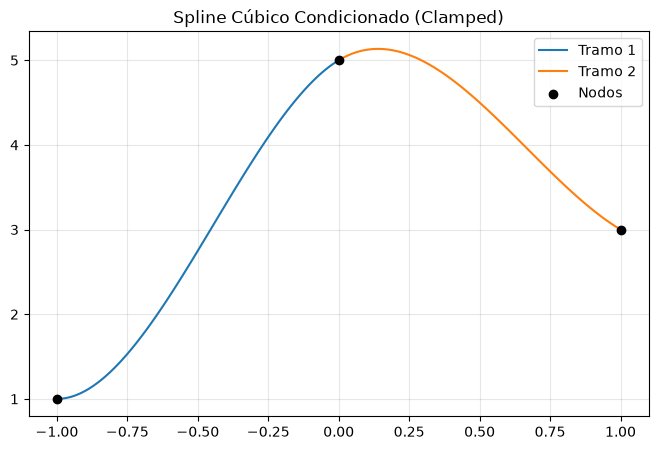

In [8]:
# Spline Cúbico Condicionado
import numpy as np

def spline_cubico_condicionado(x_datos, y_datos, fpo, fpn):
    """
    Construye un Spline Cúbico Condicionado (Clamped Spline) a partir de puntos dados.
    Requiere las pendientes extremas fpo (FPO) y fpn (FPN).
    Sigue el pseudocódigo clásico de Burden & Faires.
    """
    # ENTRADA: n, x_0, ..., x_n, a_0, ..., a_n, FPO, FPN
    x = np.array(x_datos, dtype=float)
    a = np.array(y_datos, dtype=float)
    n = len(x) - 1  # Ya que los índices van de 0 a n
    
    # Inicialización de arreglos para coeficientes y variables del sistema tridiagonal
    h = np.zeros(n)
    alpha = np.zeros(n + 1)  # Nota: aquí alpha necesita llegar hasta el índice n
    l = np.zeros(n + 1)
    mu = np.zeros(n + 1)
    z = np.zeros(n + 1)
    
    c = np.zeros(n + 1)
    b = np.zeros(n)
    d = np.zeros(n)
    
    # Paso 1: Calcular las distancias h_i
    for i in range(n):
        h[i] = x[i+1] - x[i]
        
    # Paso 2: Calcular alpha_0 y alpha_n usando las derivadas de frontera (FPO y FPN)
    alpha[0] = 3 * (a[1] - a[0]) / h[0] - 3 * fpo
    alpha[n] = 3 * fpn - 3 * (a[n] - a[n-1]) / h[n-1]
        
    # Paso 3: Calcular el resto de los alpha_i para los puntos internos
    for i in range(1, n):
        alpha[i] = (3 / h[i]) * (a[i+1] - a[i]) - (3 / h[i-1]) * (a[i] - a[i-1])
        
    # Paso 4: Condiciones iniciales para el sistema tridiagonal acondicionado
    l[0] = 2 * h[0]
    mu[0] = 0.5
    z[0] = alpha[0] / l[0]
    
    # Paso 5: Sustitución hacia adelante para los puntos internos
    for i in range(1, n):
        l[i] = 2 * (x[i+1] - x[i-1]) - h[i-1] * mu[i-1]
        mu[i] = h[i] / l[i]
        z[i] = (alpha[i] - h[i-1] * z[i-1]) / l[i]
        
    # Paso 6: Condiciones finales modificadas para la frontera rígida
    l[n] = h[n-1] * (2.0 - mu[n-1])
    z[n] = (alpha[n] - h[n-1] * z[n-1]) / l[n]
    c[n] = z[n]
    
    # Paso 7: Sustitución hacia atrás para obtener los coeficientes finales
    for j in range(n - 1, -1, -1):
        c[j] = z[j] - mu[j] * c[j+1]
        b[j] = (a[j+1] - a[j]) / h[j] - h[j] * (c[j+1] + 2 * c[j]) / 3
        d[j] = (c[j+1] - c[j]) / (3 * h[j])
        
    # Paso 8: SALIDA (a, b, c, d para j = 0, ..., n-1)
    return a[:n], b, c[:n], d



## Uso y Grafica
import matplotlib.pyplot as plt

# Puntos por donde debe pasar el spline
x_nodos = [-1,0,1]
y_nodos = [1,5,3]

# Forzamos las pendientes en los extremos:
FPO = 0.0  # Empieza totalmente plano
FPN = -2.0  # Termina subiendo con un ángulo marcado

# Calculamos coeficientes condicionados
a, b, c, d = spline_cubico_condicionado(x_nodos, y_nodos, FPO, FPN)
## Mostrar los dos splines (tramos) como polinomios explícitos
import sympy as sp

x_sym = sp.Symbol('x')



splines = []
for j in range(len(x_nodos) - 1):
    dx = x_sym - x_nodos[j]
    expr = a[j] + b[j]*dx + c[j]*dx**2 + d[j]*dx**3
    expr_expandida = sp.expand(expr)
    splines.append(expr_expandida)
    
    print(f"\nTramo {j+1}  (válido para x en [{x_nodos[j]}, {x_nodos[j+1]}]):")
    print(f"  En forma (x - x{j}):")
    print(f"    S_{j}(x) = {a[j]:.6f} + ({b[j]:.6f})(x-{x_nodos[j]}) "
          f"+ ({c[j]:.6f})(x-{x_nodos[j]})^2 + ({d[j]:.6f})(x-{x_nodos[j]})^3")
    print(f"  Expandido:")
    print(f"    S_{j}(x) = {expr_expandida}")


# Graficamos
plt.figure(figsize=(8, 5))
for j in range(len(x_nodos) - 1):
    x_tramo = np.linspace(x_nodos[j], x_nodos[j+1], 100)
    dx = x_tramo - x_nodos[j]
    y_tramo = a[j] + b[j]*dx + c[j]*(dx**2) + d[j]*(dx**3)
    plt.plot(x_tramo, y_tramo, label=f'Tramo {j+1}')

plt.scatter(x_nodos, y_nodos, color='black', zorder=5, label='Nodos')
plt.title('Spline Cúbico Condicionado (Clamped)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()